In [4]:
!pip install --upgrade google-api-python-client google-auth-httplib2 google-auth-oauthlib


   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB 1.9 MB/s eta 0:00:07
   ---------------------------------------- 0.1/12.7 MB 975.2 kB/s eta 0:00:13
   ---------------------------------------- 0.1/12.7 MB 930.9 kB/s eta 0:00:14
   ---------------------------------------- 0.1/12.7 MB 847.9 kB/s eta 0:00:15
   ---------------------------------------- 0.2/12.7 MB 762.6 kB/s eta 0:00:17
    --------------------------------------- 0.2/12.7 MB 655.4 kB/s eta 0:00:20
    --------------------------------------- 0.2/12.7 MB 653.6 kB/s eta 0:00:20
    --------------------------------------- 0.2/12.7 MB 621.6 kB/s eta 0:00:21
    --------------------------------------- 0.2/12.7 MB 576.2 kB/s eta 0:00:22
    --------------------------------------- 0.3/12.7 MB 603.8 kB/s eta 0:00:21
    --------------------------------------- 0.3/12.7 MB 593.9 kB/s eta 0

In [5]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
#from keras.layers.normalization import BatchNormalization
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Input, Lambda, Dense, Flatten, Activation, Dropout
#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import applications

ModuleNotFoundError: No module named 'cv2'

In [7]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [8]:
!ls /content/drive/MyDrive/major_project/Indian_Snakes/

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
train = list(os.walk('/content/drive/MyDrive/major_project/Indian_Snakes')) #gives the list of all directories and subdirectories
print(train)

[('/content/drive/MyDrive/major_project/Indian_Snakes', ['Dekay_brown_snake', 'common_indian_cat_snake', 'eastern_ratsnake', 'indian_common_krait_snake', 'indian_rat_snake', 'indian_rock_python', 'indian_smooth_snake', 'travancore_wolf_snake', 'Common_Sand_Boa', 'Marcy_garter_snake', 'common_wolf_snake', 'eastern_cottonmouth', 'indian_saw_scaled_viper', 'russell_s_viper', 'spectacled_cobra', 'Brahminy_Worm'], []), ('/content/drive/MyDrive/major_project/Indian_Snakes/Dekay_brown_snake', [], ['Dekay_brown_snake_115.jpg', 'Dekay_brown_snake_186.jpg', 'Dekay_brown_snake_151.jpg', 'Dekay_brown_snake_306.jpg', 'Dekay_brown_snake_65.jpg', 'Dekay_brown_snake_72.jpg', 'Dekay_brown_snake_166.jpg', 'Dekay_brown_snake_296.jpg', 'Dekay_brown_snake_262.jpg', 'Dekay_brown_snake_291.jpg', 'Dekay_brown_snake_259.jpg', 'Dekay_brown_snake_66.jpg', 'Dekay_brown_snake_233.jpg', 'Dekay_brown_snake_204.jpg', 'Dekay_brown_snake_227.jpg', 'Dekay_brown_snake_389.jpg', 'Dekay_brown_snake_315.jpg', 'Dekay_brown_s

In [ ]:
label_names = train[0][1]
dict_labels = dict(zip(label_names, list(range(len(label_names)))))
print(dict_labels)

{'Dekay_brown_snake': 0, 'common_indian_cat_snake': 1, 'eastern_ratsnake': 2, 'indian_common_krait_snake': 3, 'indian_rat_snake': 4, 'indian_rock_python': 5, 'indian_smooth_snake': 6, 'travancore_wolf_snake': 7, 'Common_Sand_Boa': 8, 'Marcy_garter_snake': 9, 'common_wolf_snake': 10, 'eastern_cottonmouth': 11, 'indian_saw_scaled_viper': 12, 'russell_s_viper': 13, 'spectacled_cobra': 14, 'Brahminy_Worm': 15}


In [ ]:
def dataset(path):
    images = []
    labels = []
    for folder in tqdm(os.listdir(path)):
        value_of_label = dict_labels[folder] # dict_labels is the dictionary whose key:value pairs are classes:numbers representing them

        for file in os.listdir(os.path.join(path, folder)):
            path_of_file = os.path.join(os.path.join(path, folder), file)
            #print("Processing:", path_of_file)  # Print the path for debugging

            # Error handling for reading images
            image = cv2.imread(path_of_file)
            if image is None or image.size == 0:
                print(f"Failed to read or empty image: {path_of_file}")
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (150, 150))
            images.append(image)
            labels.append(value_of_label)

    images = np.array(images, dtype='float32') / 255.0
    labels = np.array(labels)

    return images, labels

images, labels = dataset('/content/drive/MyDrive/major_project/Indian_Snakes')
images, labels = shuffle(images, labels)

100%|██████████| 16/16 [03:23<00:00, 12.73s/it]


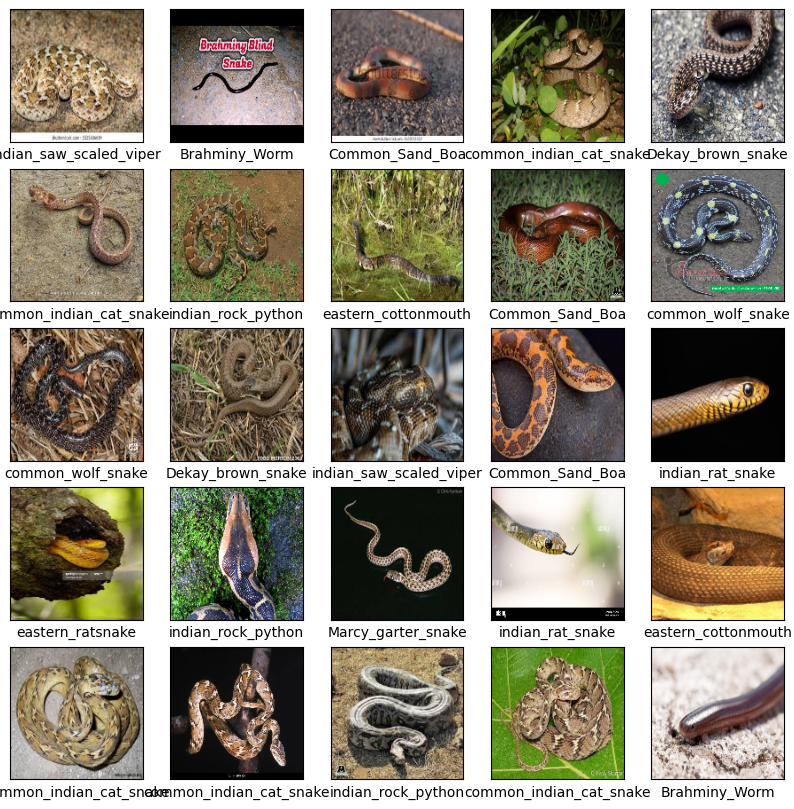

In [ ]:
plt.figure(figsize = (10,10))
for _ in range(25):
    plt.subplot(5, 5, _+1)
    plt.yticks([])
    plt.xticks([])
    plt.grid(False)
    data = images[_]
    plt.xlabel(label_names[labels[_]])
    plt.imshow(data);

In [ ]:
image_size = (224, 224)
batch_size = 64
train_datagen = ImageDataGenerator(rescale = 1./255,
                            shear_range = 0.4,
                            zoom_range = 0.4,
                            horizontal_flip = True,
                            vertical_flip = True,
                            validation_split = 0.2)

In [ ]:
train_ds = train_datagen.flow_from_directory('/content/drive/MyDrive/major_project/Indian_Snakes',
                                      target_size = image_size,
                                      batch_size = batch_size,
                                      class_mode = 'categorical',
                                      subset = 'training',
                                      color_mode="rgb",)

val_ds = train_datagen.flow_from_directory('/content/drive/MyDrive/major_project/Indian_Snakes',
                                      target_size = image_size,
                                      batch_size = batch_size,
                                      class_mode = 'categorical',
                                      subset = 'validation',
                                      color_mode="rgb")

Found 3446 images belonging to 16 classes.
Found 855 images belonging to 16 classes.


In [ ]:
train_ds.class_indices

{'Brahminy_Worm': 0,
 'Common_Sand_Boa': 1,
 'Dekay_brown_snake': 2,
 'Marcy_garter_snake': 3,
 'common_indian_cat_snake': 4,
 'common_wolf_snake': 5,
 'eastern_cottonmouth': 6,
 'eastern_ratsnake': 7,
 'indian_common_krait_snake': 8,
 'indian_rat_snake': 9,
 'indian_rock_python': 10,
 'indian_saw_scaled_viper': 11,
 'indian_smooth_snake': 12,
 'russell_s_viper': 13,
 'spectacled_cobra': 14,
 'travancore_wolf_snake': 15}

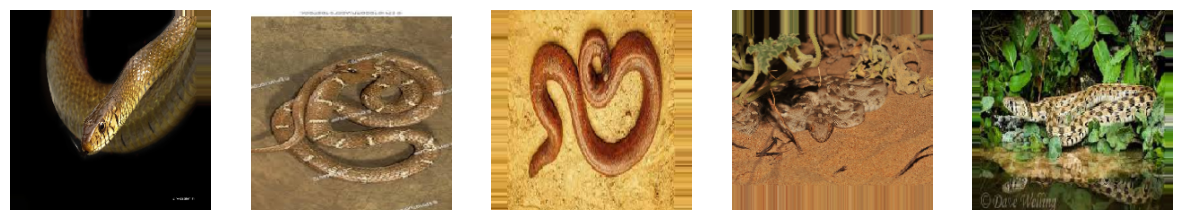

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,15))

for i in range(5):
    image = next(train_ds)[0][0]
    image = np.squeeze(image)
    ax[i].imshow(image)
    ax[i].axis(False)

In [ ]:
vgg_base = applications.VGG16(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
vgg_base.trainable = False

58889256/58889256 [==============================] - 1s 0us/step


In [ ]:
inputs = Input(shape=(224, 224, 3))
x = vgg_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(16, activation =None)(x)
vgg_model = Model(inputs, outputs)
vgg_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 16)                16400     
                                                             

In [ ]:
vgg_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy()]
)


In [ ]:
import keras

# Define the optimizer
optimizer = keras.optimizers.Adam()

# Define the loss with 'from_logits=True'
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

# Define the metrics without 'from_logits'
metrics = [keras.metrics.CategoricalAccuracy()]

# Compile the model with corrected components
vgg_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [ ]:
epochs = 25
vgg_model.fit(train_ds, epochs=epochs, validation_data=val_ds,verbose=1)

Epoch 1/25
 7/54 [==>...........................] - ETA: 29:44 - loss: 2.7885 - categorical_accuracy: 0.0871

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


24/54 [============>.................] - ETA: 19:07 - loss: 2.6206 - categorical_accuracy: 0.1113

In [ ]:
 vgg_model.save('vgg.hdf5') #this saves the model with the weights